In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from alter_surf.hamiltonian_DLKK import H_DLKK_3D_MF, Spin_operator, points_BZ
from alter_surf.mean_field import hartree_fock

In [2]:
Hparam = dict(len_z=20,delta=0.4, tp=0.3, tz=1, U=10, filling=0.49, PBC= False)
initial_parameters = dict(initial_m=(-1)**np.arange(Hparam['len_z'])/4, initial_n=Hparam['filling']*np.ones(Hparam['len_z']))

m_values, n_values, fermi_energys = hartree_fock(Hparam,initial_parameters, 40, Lq=20, tol_mdiff=1e-3,mixing_proportion=0.4,adjust_learning_rate=False)

Hparam['m_values'] = m_values[-1]
Hparam['n_values'] = n_values[-1]
Hparam['mu'] = fermi_energys[-1]


Avg:-0.00, Stag. avg:0.44, diff: 0.000246:  22%|██▎       | 9/40 [00:07<00:24,  1.27it/s]


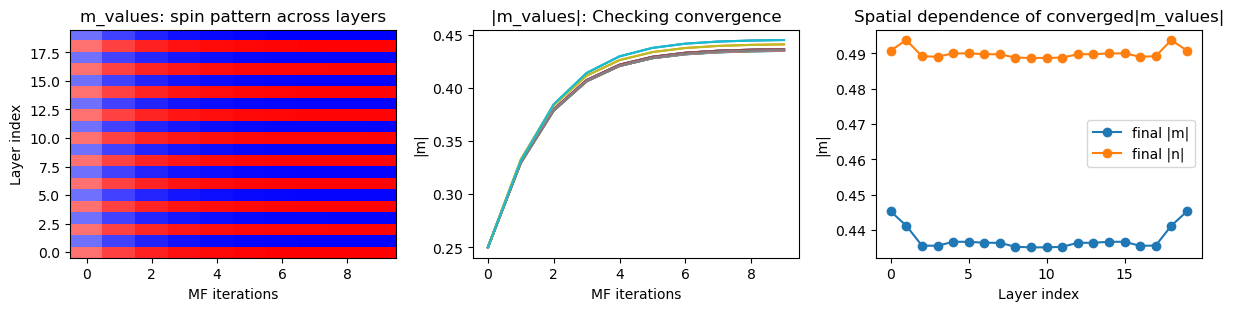

In [3]:
fig, axs = plt.subplots(1,3, figsize=(12,3), constrained_layout=True)

axs[0].set_title('m_values: spin pattern across layers')
axs[0].set_xlabel('MF iterations')
axs[0].set_ylabel('Layer index')
axs[0].imshow(m_values.T, aspect='auto', cmap='bwr',origin='lower', vmin=-m_values.max(), vmax=m_values.max())

axs[1].set_title('|m_values|: Checking convergence')
axs[1].set_xlabel('MF iterations')
axs[1].set_ylabel('|m|')
axs[1].plot(np.abs(m_values))

axs[2].set_title('Spatial dependence of converged|m_values|')
axs[2].set_xlabel('Layer index')
axs[2].set_ylabel('|m|')
axs[2].plot(np.abs(m_values[-1]),'-o',label='final |m|')
axs[2].plot(np.abs(n_values[-1]),'-o',label='final |n|')
axs[2].legend()

/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:94: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_under(color='black')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:95: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_over(color='gray')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:25: MatplotlibDeprecationWarning: You are modifying the state of a globally r

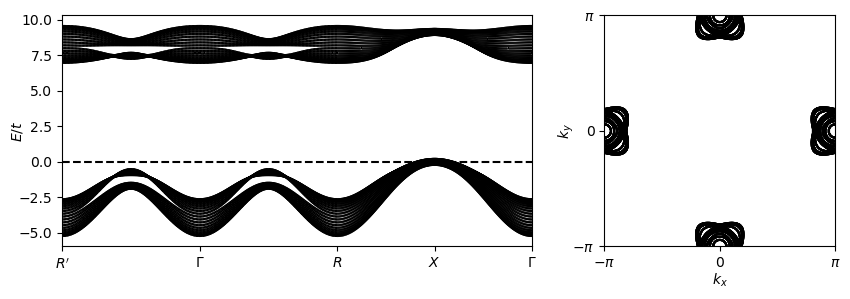

In [ ]:
from blochK.plotting import plot_FS, plot_bandstruc

param = Hparam

labels = ["R'",'\Gamma','R',"X",'\Gamma']
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]

coloring_operator = np.kron(np.ones(param['len_z']), Spin_operator)

cmap = 'bwr'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H_DLKK_3D_MF,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK_3D_MF,param=param,coloring_operator=coloring_operator,cmap=cmap)


      converged: True
           flag: 'converged'
 function_calls: 3
     iterations: 1
           root: 4.710115884242322